# Import Libraries

In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Read Datasets

In [71]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
gender_submission_df = pd.read_csv("gender_submission.csv")

# Data Cleaning and Preprocessing

In [72]:
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
test_df['Age'].fillna(test_df['Age'].median(), inplace=True)

train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)
test_df['Embarked'].fillna(test_df['Embarked'].mode()[0], inplace=True)

train_df.drop(columns=['Cabin', 'Ticket', 'Name'], inplace=True)
test_df.drop(columns=['Cabin', 'Ticket', 'Name'], inplace=True)

print("Data Cleaning Completed. Missing values handled and unnecessary columns dropped.")
print("Train Data after Cleaning:")
print(train_df.head())
print("Test Data after Cleaning:")
print(test_df.head())

Data Cleaning Completed. Missing values handled and unnecessary columns dropped.
Train Data after Cleaning:
   PassengerId  Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0            1         0       3    male  22.0      1      0   7.2500        S
1            2         1       1  female  38.0      1      0  71.2833        C
2            3         1       3  female  26.0      0      0   7.9250        S
3            4         1       1  female  35.0      1      0  53.1000        S
4            5         0       3    male  35.0      0      0   8.0500        S
Test Data after Cleaning:
   PassengerId  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0          892       3    male  34.5      0      0   7.8292        Q
1          893       3  female  47.0      1      0   7.0000        S
2          894       2    male  62.0      0      0   9.6875        Q
3          895       3    male  27.0      0      0   8.6625        S
4          896       3  female  22.0      1    

<ipython-input-72-6eb3b99fbb66>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
<ipython-input-72-6eb3b99fbb66>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [73]:
label_enc = LabelEncoder()
train_df['Sex'] = label_enc.fit_transform(train_df['Sex'])
test_df['Sex'] = label_enc.transform(test_df['Sex'])

train_df['Embarked'] = label_enc.fit_transform(train_df['Embarked'])
test_df['Embarked'] = label_enc.transform(test_df['Embarked'])

In [74]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['FarePerPerson'] = train_df['Fare'] / train_df['FamilySize']

train_df[['FamilySize', 'FarePerPerson']].head()

,FamilySize,FarePerPerson
0,2,3.62500
1,2,35.64165
2,1,7.92500
3,2,26.55000
4,1,8.05000


In [75]:
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,FarePerPerson
0,1,0,3,1,22.0,1,0,7.2500,2,2,3.62500
1,2,1,1,0,38.0,1,0,71.2833,0,2,35.64165
2,3,1,3,0,26.0,0,0,7.9250,2,1,7.92500
3,4,1,1,0,35.0,1,0,53.1000,2,2,26.55000
4,5,0,3,1,35.0,0,0,8.0500,2,1,8.05000


In [76]:
test_df.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,1,34.5,0,0,7.8292,1
1,893,3,0,47.0,1,0,7.0000,2
2,894,2,1,62.0,0,0,9.6875,1
3,895,3,1,27.0,0,0,8.6625,2
4,896,3,0,22.0,1,1,12.2875,2


In [77]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
FamilySize,0


In [78]:
train_df.to_csv('train_preprocessed.csv', index=False)
test_df.to_csv('test_preprocessed.csv', index=False)

# Descriptive Statistics

In [79]:
print("Train Data Info:")
print(train_df.info())
print("Test Data Info:")
print(test_df.info())

Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Survived       891 non-null    int64  
 2   Pclass         891 non-null    int64  
 3   Sex            891 non-null    int64  
 4   Age            891 non-null    float64
 5   SibSp          891 non-null    int64  
 6   Parch          891 non-null    int64  
 7   Fare           891 non-null    float64
 8   Embarked       891 non-null    int64  
 9   FamilySize     891 non-null    int64  
 10  FarePerPerson  891 non-null    float64
dtypes: float64(3), int64(8)
memory usage: 76.7 KB
None
Test Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1  

In [80]:
train_df.describe(include='all')

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,FarePerPerson
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.647587,29.361582,0.523008,0.381594,32.204208,1.536476,1.904602,19.916375
std,257.353842,0.486592,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429,0.791503,1.613459,35.841257
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,1.000000,1.000000,7.250000
50%,446.000000,0.000000,3.000000,1.000000,28.000000,0.000000,0.000000,14.454200,2.000000,1.000000,8.300000
75%,668.500000,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,2.000000,2.000000,23.666667
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000,11.000000,512.329200


In [81]:
# Value counts for categorical features
train_df['Sex'].value_counts(), train_df['Embarked'].value_counts(), train_df['Pclass'].value_counts()

(Sex
 1    577
 0    314
 Name: count, dtype: int64,
 Embarked
 2    646
 0    168
 1     77
 Name: count, dtype: int64,
 Pclass
 3    491
 1    216
 2    184
 Name: count, dtype: int64)

# Data Visualization

<Figure size 1200x600 with 0 Axes>

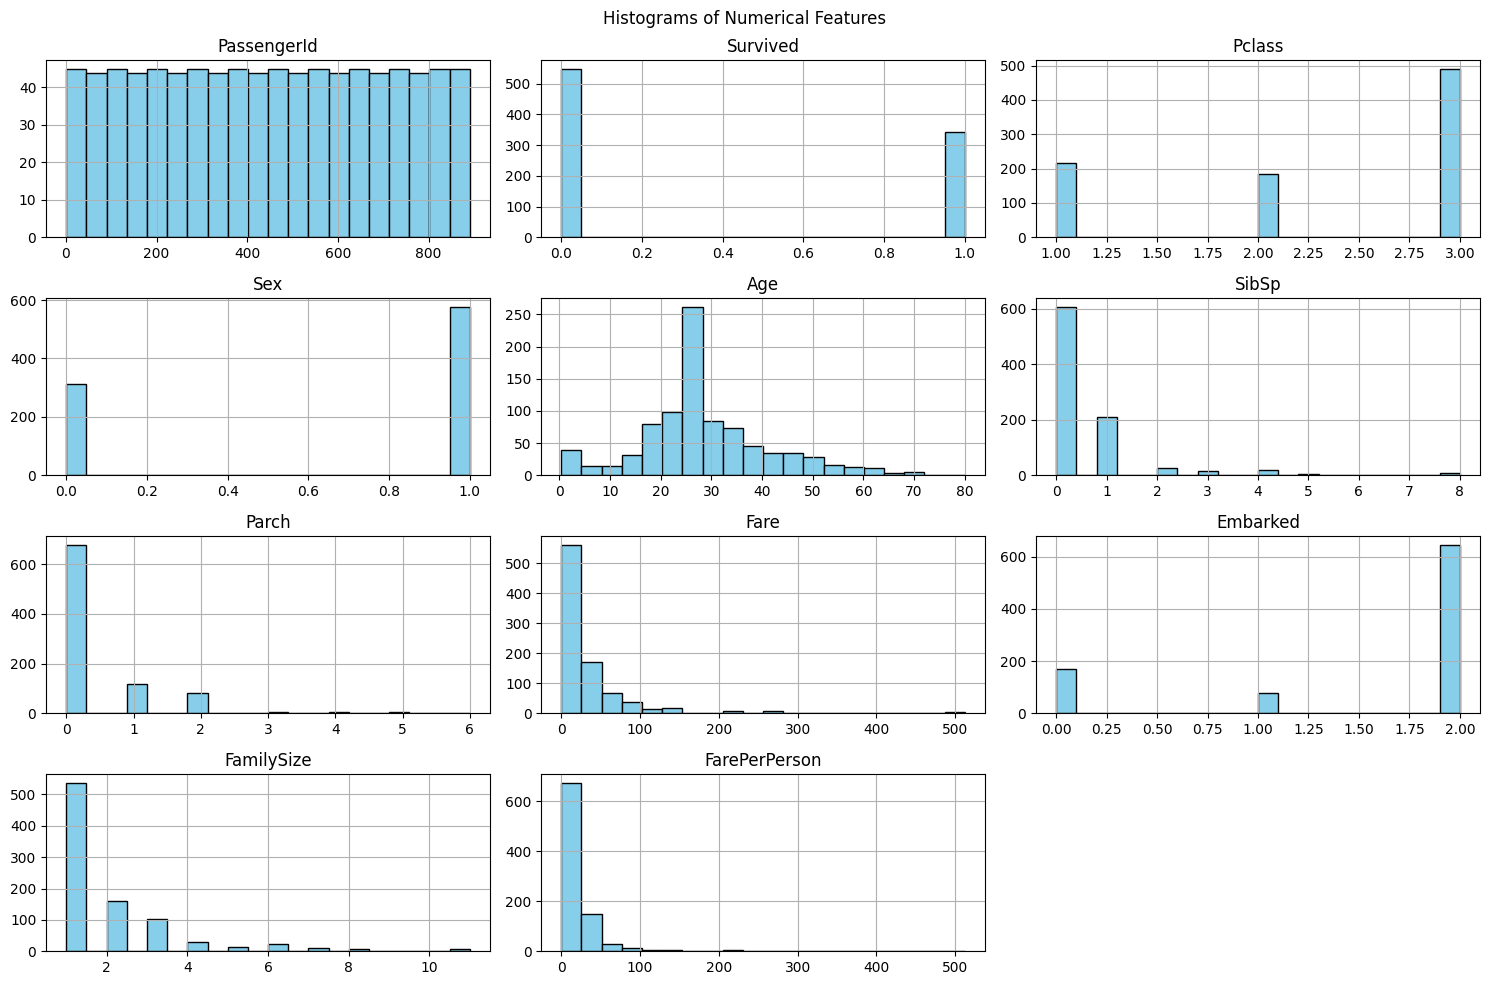

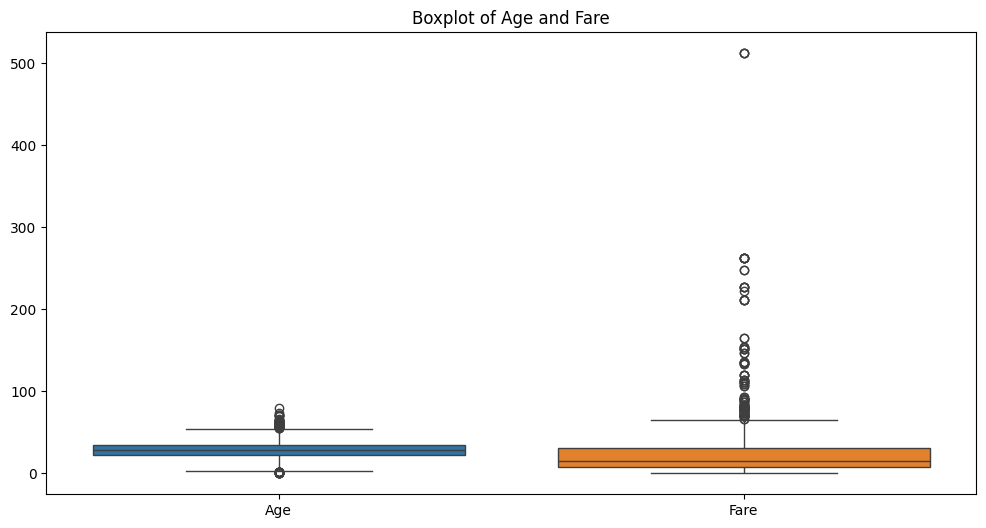

In [82]:
# Univariate Analysis

# Histogram
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
train_df.hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()

# Boxplots to identify outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df[['Age', 'Fare']])
plt.title("Boxplot of Age and Fare")
plt.show()

**Observation:** Age and Fare show the presence of outliers.

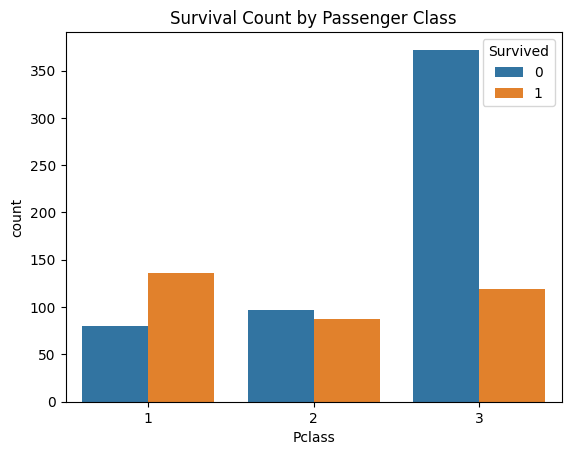

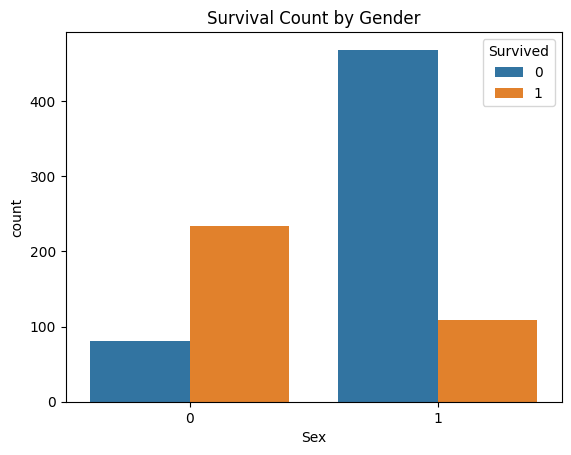

In [83]:
# Bivariate Analysis

# Survival by class and gender
sns.countplot(data=train_df, x='Pclass', hue='Survived')
plt.title("Survival Count by Passenger Class")
plt.show()

sns.countplot(data=train_df, x='Sex', hue='Survived')
plt.title("Survival Count by Gender")
plt.show()

**Observation:** Women and passengers in higher classes had higher survival rates.

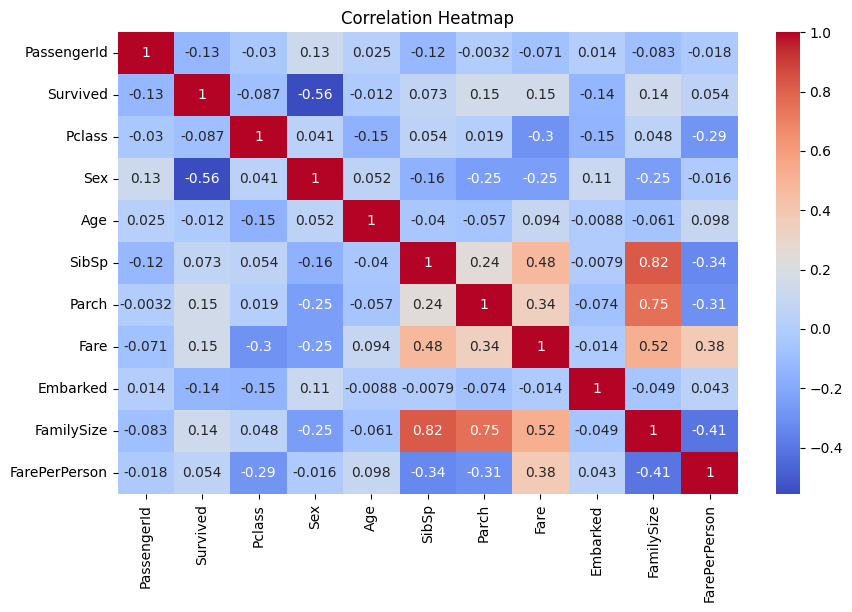

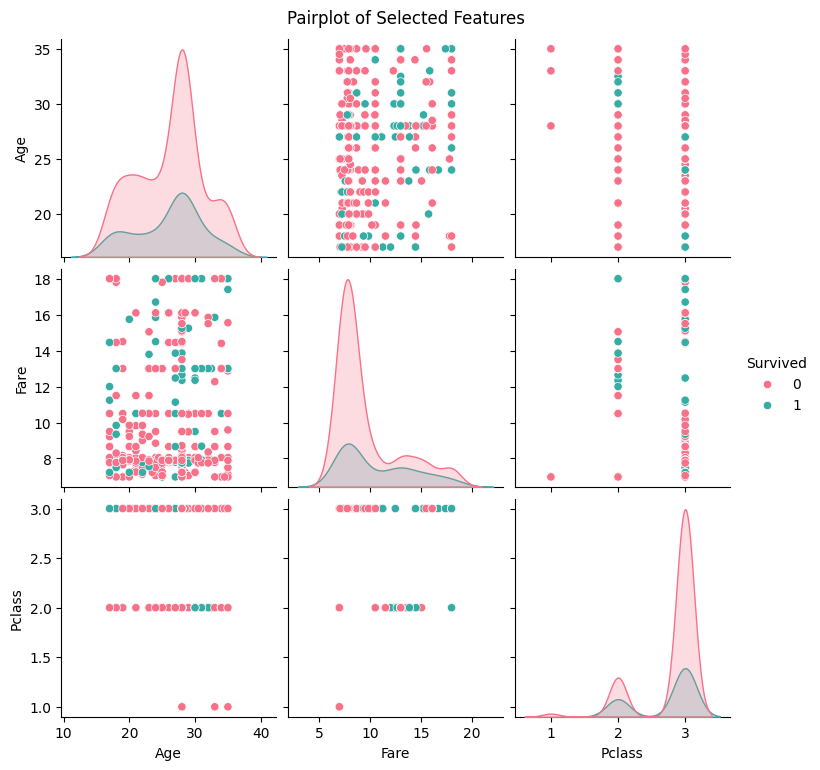


Data Preprocessing and EDA completed successfully.


In [67]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(train_df[['Survived', 'Age', 'Fare', 'Pclass']], hue='Survived', palette='husl')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

print("\n\033[1mData Preprocessing and EDA completed successfully.\033[0m")

**Observation:** Fare and Pclass seem to influence survival. Some relationships are nonlinear.

## Summary of Findings

- Passengers in 1st class had higher chances of survival.
- Females had a much higher survival rate than males.
- Higher fares correlated with higher survival probability.
- Outliers are present in Age and Fare columns.
- Some missing data needs to be addressed (Age, Embarked).